# Week 8 Lab: Fine-tune a small LLM with LoRA for a domain task

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, 3, 4

**Scenario.** A bank's support team wants incoming customer messages routed to the right intent. We adapt a small open LLM (**Qwen2.5-0.5B-Instruct**) to this domain and **measure** whether fine-tuning beats prompting.

1. Prepare a domain dataset (Banking77, 10 intents) in **chat format**, with a held-out test set.
2. Measure **prompting baselines** (zero-shot, few-shot) on the base model.
3. Add **LoRA** adapters with Hugging Face **PEFT** and count trainable parameters.
4. **Supervised fine-tuning** (SFT) with Hugging Face **TRL**.
5. Compare **base vs fine-tuned** on the same held-out test set; analyse errors.
6. Check for **forgetting**, switch the adapter off and on, and compare adapter size with model size.

**Runtime:** Colab → **T4 GPU** (training ≈ 5–8 minutes). A CPU works for the smoke test only.

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **T4 GPU**. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. A GPU is optional: every cell has a CPU-friendly setting.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete. Questions marked ✍️ need a short written answer.

## Start here: what changes during fine-tuning?

Customer messages and known intent labels become training pairs. A pretrained
model already supplies general language patterns. LoRA freezes its base
weights and adds small trainable correction matrices. Supervised fine-tuning
uses the known label tokens to teach those corrections. The test set checks
whether the resulting classifier improves on the prompting baselines.

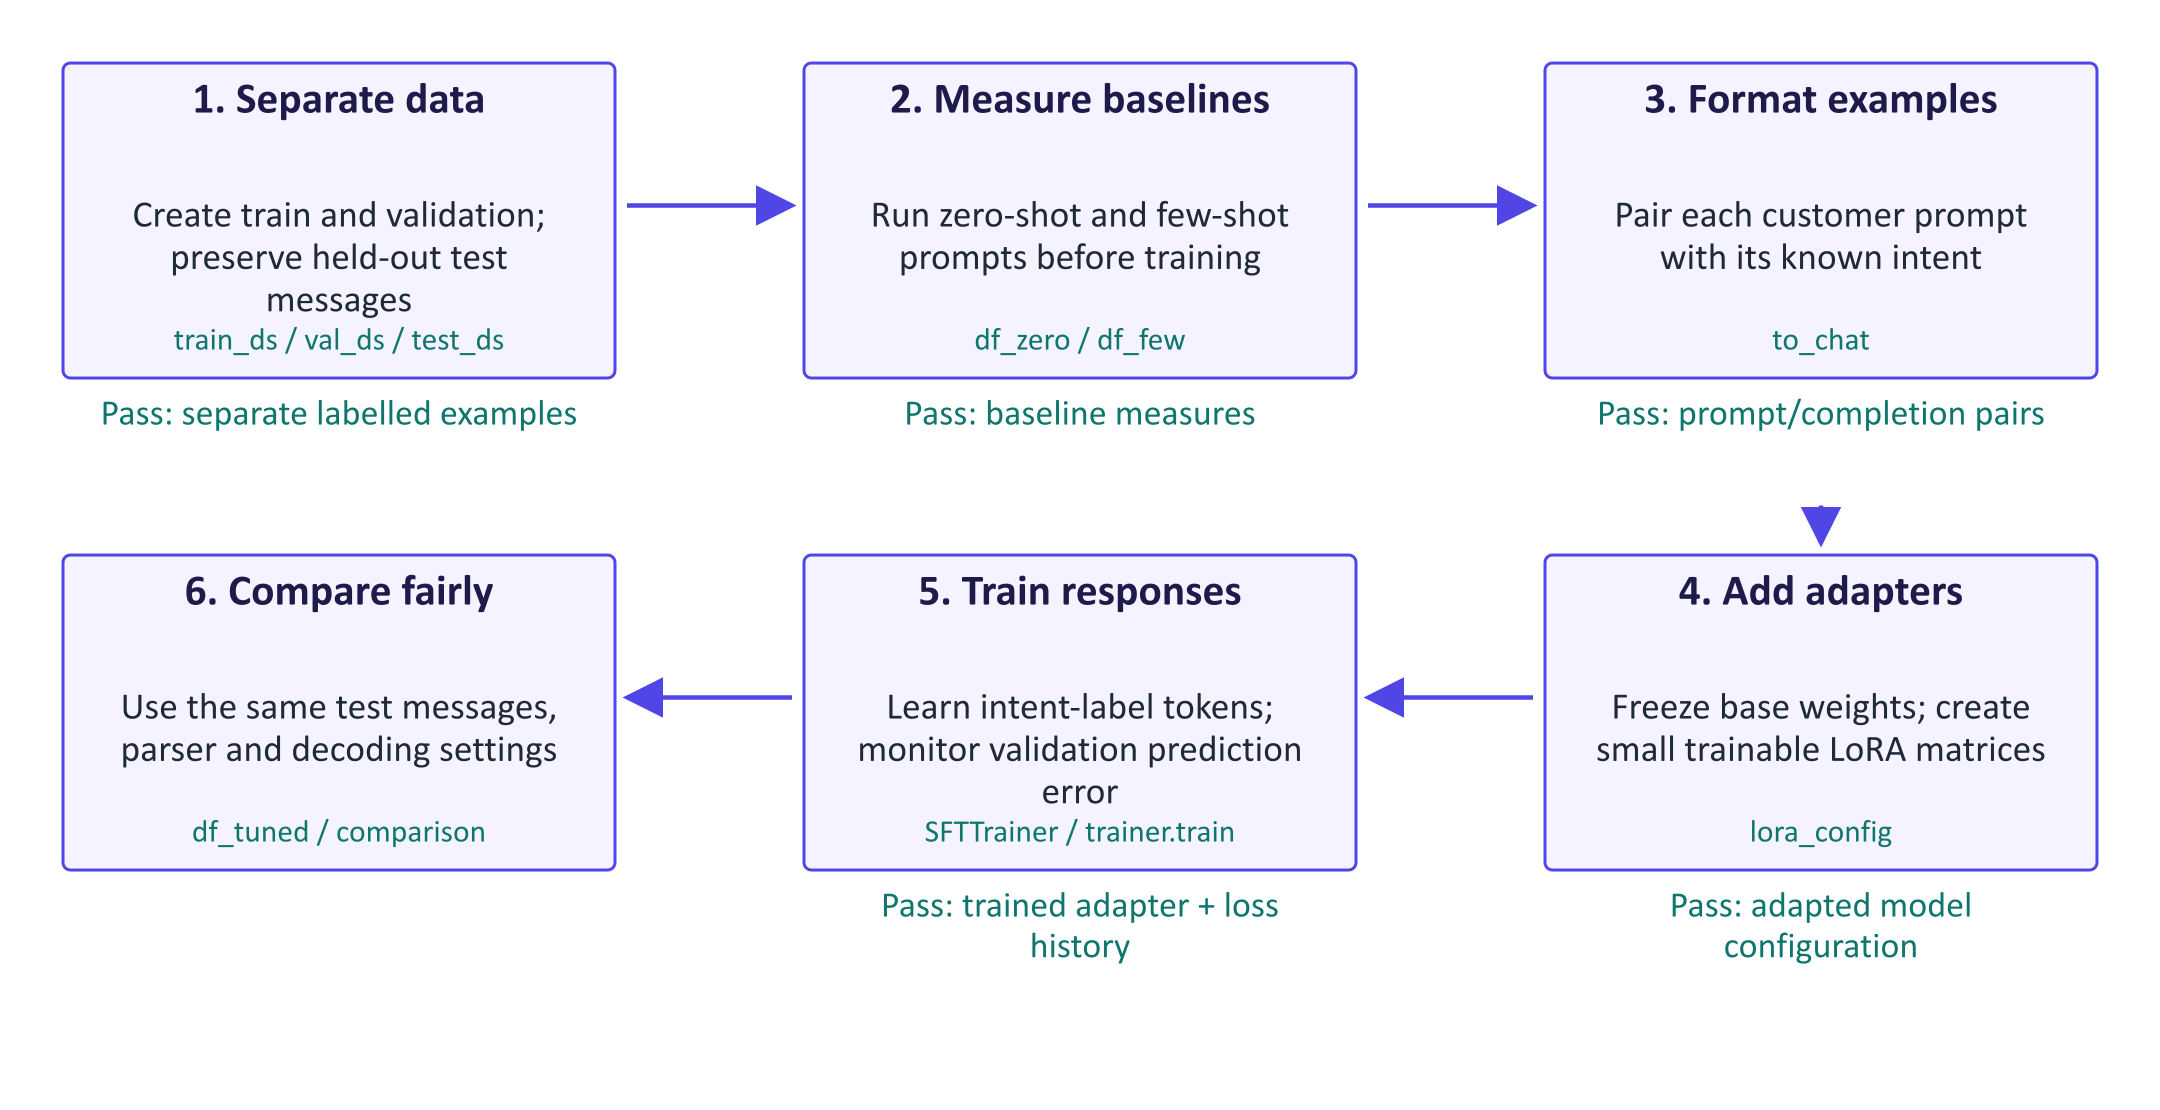

## Your map from the workflow to code

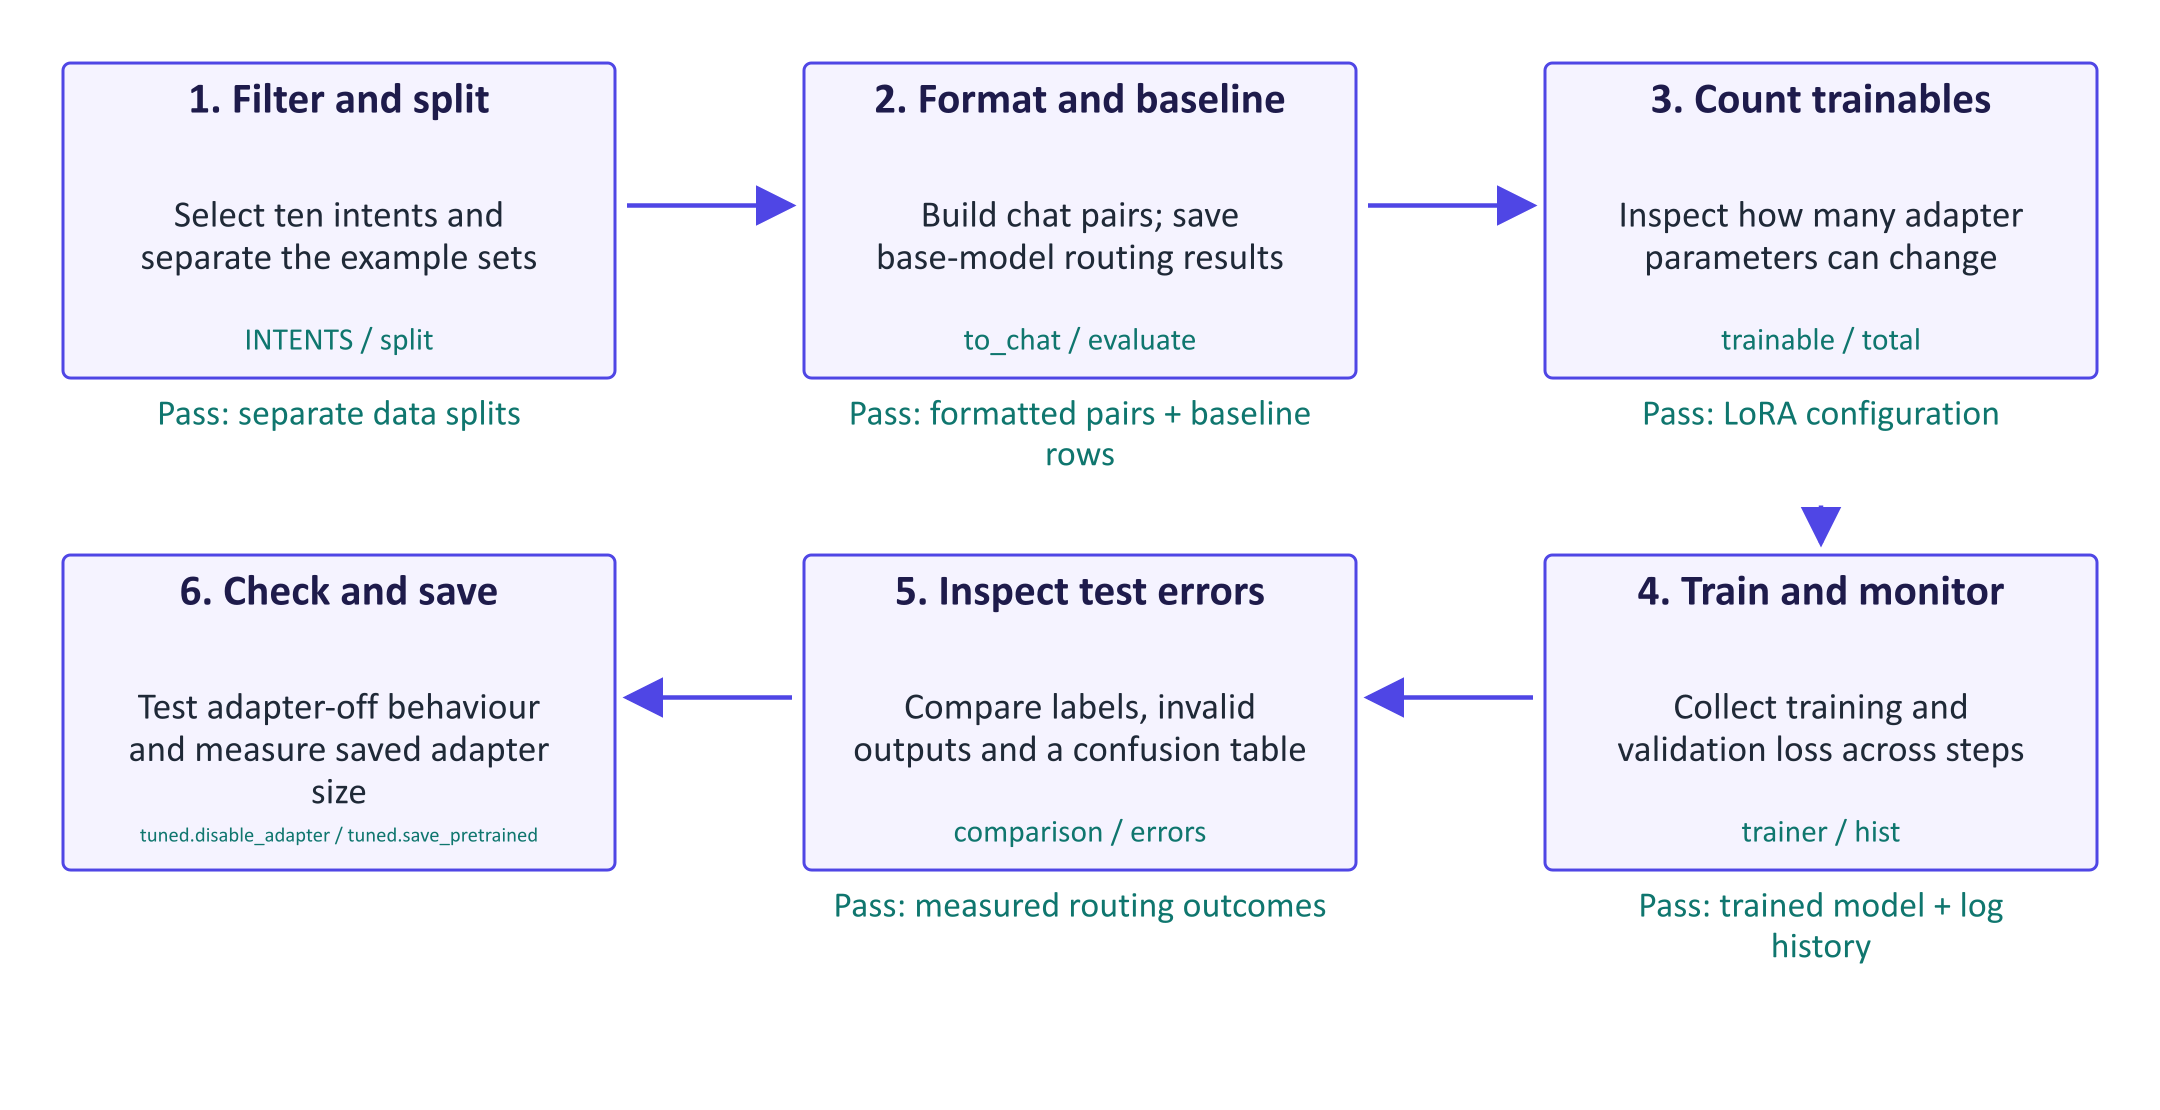

| Block in the map | Find this code | Observe this |
|---|---|---|
| Filter and split | `INTENTS`, `train_ds`, `val_ds`, `test_ds` | Which examples serve each purpose |
| Format and baseline | `to_chat`, `evaluate` | Prompt/completion boundaries and base predictions |
| Count trainables | `lora_config`, `trainable`, `total` | Which parameters can change |
| Train and monitor | `trainer`, `hist` | Training and validation loss together |
| Inspect test errors | `comparison`, `errors` | Valid labels, wrong decisions and unparsed outputs |
| Check and save | `disable_adapter`, `save_pretrained` | Active-adapter behaviour and the saved artifact |

SFT names the training objective and example format; LoRA names the parameter
update method. They work together here. A lower training loss is useful
evidence of learning, but held-out decisions determine task performance.

In [ ]:
%pip install -q transformers accelerate datasets peft trl pandas matplotlib

In [ ]:
import os
import random
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import Dataset, load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
random.seed(0)
torch.manual_seed(0)
print("device:", DEVICE)

## Part 1 · Domain data in chat format

Banking77 contains real customer-support messages labelled with 77 intents (licence CC-BY-4.0). We use **10 intents**.

In [ ]:
INTENTS = ["card_arrival", "lost_or_stolen_card", "exchange_rate", "top_up_failed", "pending_transfer",
           "activate_my_card", "cash_withdrawal_charge", "verify_my_identity", "age_limit", "Refund_not_showing_up"]
raw = load_dataset("mteb/banking77")
keep = lambda ex: ex["label_text"] in INTENTS  # noqa: E731
train_full = raw["train"].filter(keep).shuffle(seed=0)
test_full = raw["test"].filter(keep).shuffle(seed=0)
split = train_full.train_test_split(test_size=0.1, seed=0)
# Validation comes from the training source; test_full remains a separate source.
train_ds, val_ds = split["train"], split["test"]
N_TEST = 30 if SMOKE else 200
test_ds = test_full.select(range(N_TEST))
print(f"train {len(train_ds)} | validation {len(val_ds)} | test {len(test_ds)}")
pd.Series(train_ds["label_text"]).value_counts()

**TODO 1:** write `to_chat(example)` returning a **prompt–completion** pair in conversational form:

* `prompt`: a list with one user message: `"Classify the banking customer message into one intent.\nIntents: <comma-separated list>\nMessage: <text>\nIntent:"`
* `completion`: a list with one assistant message whose content is the intent label.

TRL trains only on the **completion** tokens (the prompt is masked out of the loss).

In [ ]:
INSTRUCTION = "Classify the banking customer message into one intent.\nIntents: " + ", ".join(INTENTS)


def to_chat(example):
    pass  # TODO: write your code here


sft_train = train_ds.map(to_chat, remove_columns=train_ds.column_names)
sft_val = val_ds.map(to_chat, remove_columns=val_ds.column_names)
print(sft_train[0])

## Part 2 · Baselines: prompting the base model

We reuse the idea of last week's harness: fixed model, greedy decoding, exact-match accuracy on the held-out test set.

In [ ]:
tok = AutoTokenizer.from_pretrained(MODEL_ID)
base = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE).eval()


@torch.no_grad()
def predict(model, messages, max_new_tokens=32):
    inputs = tok.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt", return_dict=True).to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()


# A lenient parser, so the baselines are not punished for wrapping the label in a sentence ("Intent: age_limit",
# "The intent is \"age limit\""): the prediction is the first intent label mentioned, with spaces or underscores.
LABEL_RE = {lab: re.compile(r"(?<![a-z])" + lab.lower().replace("_", "[ _]") + r"(?![a-z])") for lab in INTENTS}


def normalise(text):
    hits = [(m.start(), lab) for lab, pattern in LABEL_RE.items() if (m := pattern.search(text.lower()))]
    return min(hits)[1] if hits else None


def evaluate(model, make_messages, ds=test_ds, name=""):
    rows = []
    t0 = time.time()
    for ex in ds:
        raw_out = predict(model, make_messages(ex))
        # Recognition is defined by our lenient parser; it is not strict label-only output.
        pred = normalise(raw_out)
        rows.append({"text": ex["text"], "gold": ex["label_text"], "raw": raw_out, "pred": pred, "correct": pred == ex["label_text"]})
    df = pd.DataFrame(rows)
    print(f"{name:22s} accuracy {df.correct.mean():.3f} | invalid {df.pred.isna().mean():.3f} | {time.time() - t0:.0f} s")
    return df


zero = lambda ex: to_chat(ex)["prompt"]  # noqa: E731
shots = {}
for ex in train_ds:
    shots.setdefault(ex["label_text"], ex["text"])
SHOTS = "\n".join(f"Message: {t}\nIntent: {l}" for l, t in shots.items())
few = lambda ex: [{"role": "user", "content": f"{INSTRUCTION}\n\nExamples:\n{SHOTS}\n\nMessage: {ex['text']}\nIntent:"}]  # noqa: E731

df_zero = evaluate(base, zero, name="base, zero-shot")
df_few = evaluate(base, few, name="base, few-shot (10 ex.)")

In [ ]:
# What did the base model actually write? A missing label (pred = None) is a format failure; a wrong label is a decision failure.
pd.concat([df_zero.assign(prompt="zero-shot"), df_few.assign(prompt="few-shot")]).groupby("prompt").head(4)[["prompt", "gold", "raw", "pred"]]

## Part 3 · Add LoRA adapters

LoRA freezes the pretrained weight $W$ and learns a low-rank update $\Delta W = \frac{\alpha}{r} B A$ with $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times k}$.

**TODO 2:** create a `LoraConfig` with rank `r=16`, `lora_alpha=32`, `lora_dropout=0.05`, applied to the attention projections `q_proj, k_proj, v_proj, o_proj`, task type `CAUSAL_LM`. Then print the number of trainable parameters.

In [ ]:
from peft import LoraConfig, get_peft_model

pass  # TODO: write your code here

probe = get_peft_model(AutoModelForCausalLM.from_pretrained(MODEL_ID), lora_config)
trainable = sum(p.numel() for p in probe.parameters() if p.requires_grad)
total = sum(p.numel() for p in probe.parameters())
print(f"trainable parameters: {trainable:,} of {total:,} ({100 * trainable / total:.2f}%)")
del probe

## Part 4 · Supervised fine-tuning with TRL

`SFTTrainer` applies the chat template, masks the prompt, and trains only the LoRA parameters.

The completion is the known intent label, possibly represented by several
tokens. Loss evaluates those tokens. The prompt supplies context but is
excluded from that loss. Monitor validation loss alongside training loss;
validation evaluation is omitted by the short smoke-test configuration.

In [ ]:
from trl import SFTConfig, SFTTrainer

args = SFTConfig(
    output_dir="banking-lora",
    num_train_epochs=1,
    max_steps=10 if SMOKE else -1,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=5,
    logging_steps=5,
    eval_strategy="steps" if not SMOKE else "no",
    eval_steps=20,
    max_length=256,
    save_strategy="no",
    report_to="none",
    fp16=False,
    bf16=False,
    seed=0,
)
ft_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32)
trainer = SFTTrainer(model=ft_model, args=args, train_dataset=sft_train, eval_dataset=None if SMOKE else sft_val,
                     peft_config=lora_config, processing_class=tok)
t0 = time.time()
trainer.train()
train_minutes = (time.time() - t0) / 60
print(f"training took {train_minutes:.1f} min")

hist = pd.DataFrame(trainer.state.log_history)
# Training and validation entries occur on different rows of the log history.
plt.plot(hist.dropna(subset=["loss"]).step, hist.dropna(subset=["loss"]).loss, label="train loss")
if "eval_loss" in hist:
    ev = hist.dropna(subset=["eval_loss"])
    plt.plot(ev.step, ev.eval_loss, marker="o", label="validation loss")
plt.xlabel("step"); plt.ylabel("loss (completion tokens)"); plt.legend(); plt.title("LoRA SFT"); plt.show()

## Part 5 · Base vs fine-tuned on the same held-out test set

**TODO 3:** evaluate the fine-tuned model with the **zero-shot** prompt (the format it was trained on) and build a comparison table of the three results.

In [ ]:
tuned = trainer.model.eval()
pass  # TODO: write your code here
comparison

In [ ]:
errors = df_tuned[~df_tuned.correct]
print(f"{len(errors)} errors")
errors[["text", "gold", "raw"]].head(10)

In [ ]:
pd.crosstab(df_tuned.gold, df_tuned.pred.fillna("INVALID"))

✍️ **Question 1.** Compare the three rows. Why does fine-tuning help so much on this task? Look at the remaining errors: are they model errors or ambiguous labels? Would the conclusion change with a larger or a different test set?

*✍️ Write your answer here.*

## Part 6 · Forgetting, modularity and size

What happens if we ask the fine-tuned model an ordinary question? LoRA keeps the base weights frozen, so we can **switch the adapter off**.
This single question illustrates possible specialisation. It is not a broad
benchmark of retained general capabilities; use a varied regression set for that.

In [ ]:
q = [{"role": "user", "content": "In one sentence, what is the capital of France and why is it famous?"}]
print("fine-tuned (adapter on): ", predict(tuned, q, max_new_tokens=40))
with tuned.disable_adapter():
    print("adapter switched off:    ", predict(tuned, q, max_new_tokens=40))

**TODO 4:** save the adapter and compare its size on disk with the size of the full model's weights.
The adapter measure below counts files on disk; the base measure counts
parameter bytes in memory. Report those definitions with the numbers.

In [ ]:
tuned.save_pretrained("banking-lora-adapter")
adapter_mb, model_mb = 0.0, 0.0  # TODO 4
print(f"adapter: {adapter_mb:.1f} MB | full model weights (fp32): {model_mb:.0f} MB")

✍️ **Question 2.** What did the fine-tuned model do with the general question, and why? How does LoRA's modularity help in practice (think of one base model serving several departments)?

*✍️ Write your answer here.*

## Optional extensions

**QLoRA (GPU only).** Load the base model in 4-bit and train LoRA on top:

```python
from transformers import BitsAndBytesConfig
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct", quantization_config=bnb, device_map="auto")
```

**DPO (preference tuning).** With a dataset of `prompt`, `chosen`, `rejected` examples:

```python
from trl import DPOConfig, DPOTrainer
trainer = DPOTrainer(model=model, args=DPOConfig(output_dir="dpo", beta=0.1), train_dataset=prefs, processing_class=tok, peft_config=lora_config)
```

✍️ **Question 3.** Your team is choosing between (a) few-shot prompting a large API model and (b) this LoRA-tuned 0.5B model for routing 50,000 messages per day. Compare them on accuracy, cost, latency, privacy and maintenance.

*✍️ Write your answer here.*